In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pyarrow.parquet as pq
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
pq_file = pq.ParquetFile("AirNow_2025_clean.parquet")

In [ ]:
batch = next(pq_file.iter_batches(batch_size=2000000))
dfs = batch.to_pandas()
dfs = dfs.sample(frac=0.1, random_state=42)

In [ ]:
dfs.head()

,timestamp,Date,Time,SiteID,SiteName,Latitude,Longitude,StateCode,CountyName,ReportingAreaID,ReportingAreaName,Parameter,Unit,Value,CategoryNumber,CategoryName,AgencyName
1828401,2025-01-06 19:00:00,01/06/25,19:00,121171002,Seminole Community C,28.745600,-81.310000,FL,SEMINOLE,fl033,Lake County,PM2.5,UG/M3,9.6,None,None,Florida Dept. of Environmental Protection
1200071,2025-01-04 19:00:00,01/04/25,19:00,220990001,St. Martinville,30.008887,-91.869595,LA,ST. MARTIN,la005,Lafayette,OZONE,PPB,38,None,None,Louisiana Department of Environmental Quality
194849,2025-01-01 14:00:00,01/01/25,14:00,490353006,Hawthorne,40.733501,-111.871696,UT,SALT LAKE,ut001,Salt Lake City,OZONE,PPB,2,None,None,Utah Department of Environmental Quality
1629054,2025-01-06 04:00:00,01/06/25,04:00,040139997,Phoenix JLG Supersit,33.503601,-112.095001,AZ,MARICOPA,az001,Phoenix,PM10,UG/M3,72,None,None,Arizona Department of Environmental Quality
191144,2025-01-01 14:00:00,01/01/25,14:00,320030043,Paul Meyer,36.106389,-115.253333,NV,CLARK,nv001,Las Vegas,PM2.5,UG/M3,4.6,None,None,Clark County Department of Environment and Sus...


# Analyse de la concentration de PM2.5 au niveau d'une station de Philadephie

In [ ]:
station_id = "240330030"
pollutant = "PM2.5"

con = duckdb.connect()

In [ ]:
query=f"""
  SELECT timestamp, CAST(Value AS DOUBLE) AS Value
    FROM parquet_scan('AirNow_2025_clean.parquet')
    WHERE SiteID = '{station_id}'
    AND Parameter = '{pollutant}'
    AND Value IS NOT NULL
    AND CAST(Value AS DOUBLE) >= 0
    ORDER BY timestamp
"""

df=con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Nombre de points : 274521


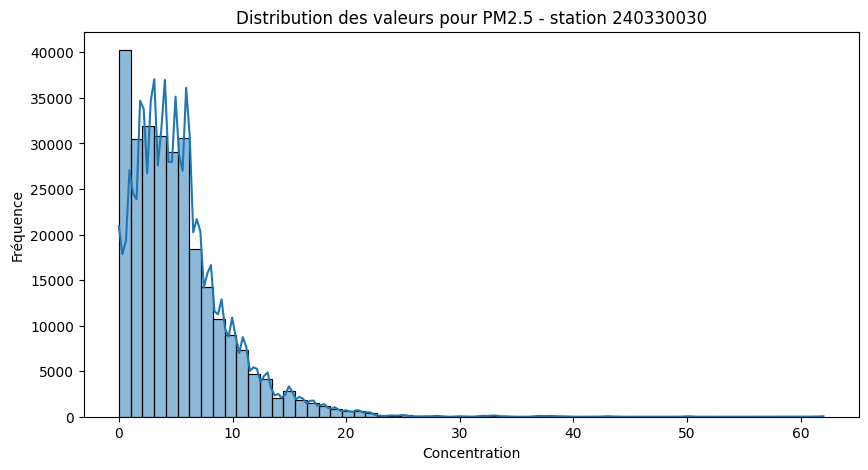

In [ ]:
df["Value"] = pd.to_numeric(df["Value"], errors="coerce").dropna()
print("Nombre de points :", len(df))

plt.figure(figsize=(10,5))
sns.histplot(df["Value"], bins=60, kde=True)
plt.title(f"Distribution des valeurs pour {pollutant} - station {station_id}")
plt.xlabel("Concentration")
plt.ylabel("Fréquence")
plt.show()

            Value
timestamp        
2025-01-01    3.0
2025-01-01    3.0
2025-01-01    3.0
2025-01-01    3.0
2025-01-01    3.0


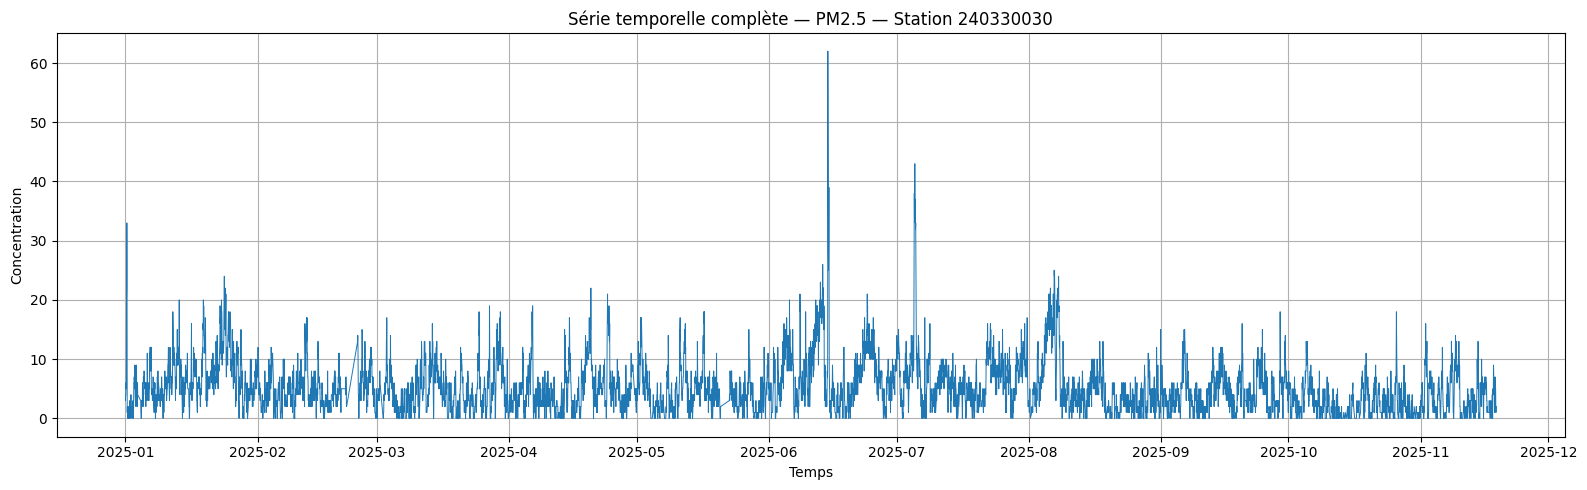

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
print(df.head())

df["Month"] = df.index.month
df["Day"] = df.index.day
df["Date"] = df.index.date

#Série de l'ensemble du dataset
plt.figure(figsize=(16,5))
plt.plot(df.index, df["Value"], linewidth=0.7)
plt.title(f"Série temporelle complète — {pollutant} — Station {station_id}")
plt.xlabel("Temps")
plt.ylabel("Concentration")
plt.grid(True)
plt.tight_layout()
plt.show()

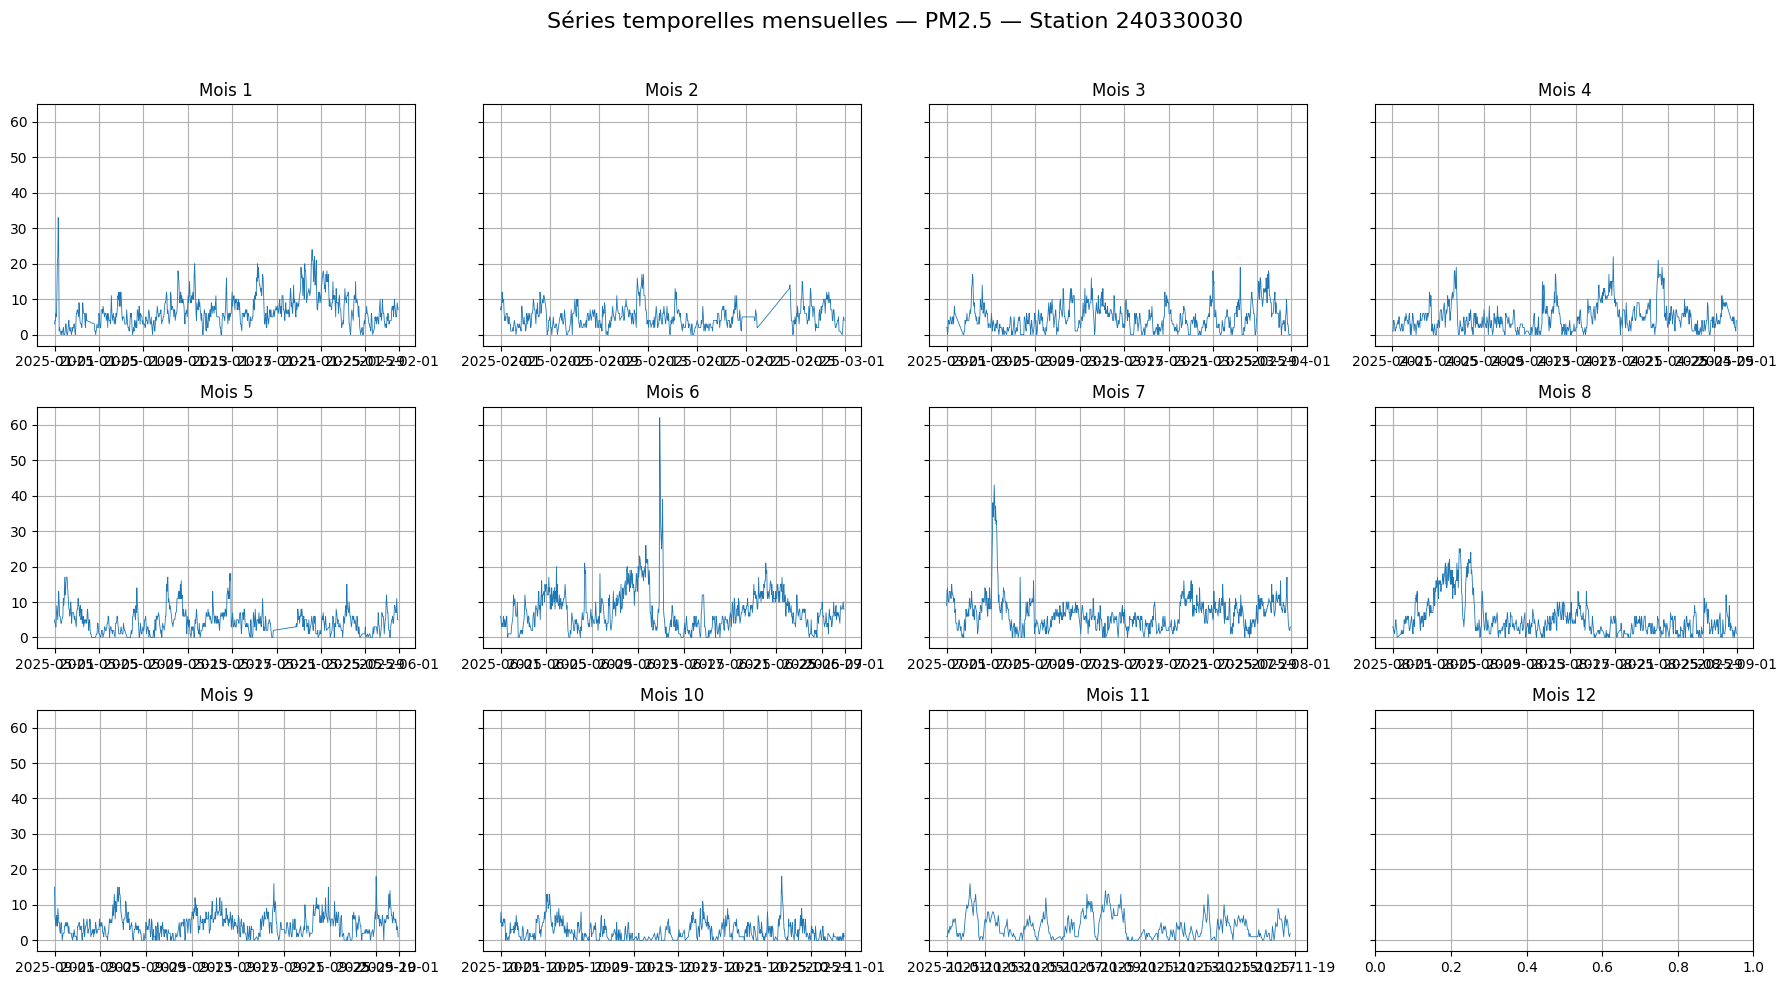

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

#Séries par mois
for month in range(1, 13):
    ax = axes[month-1]
    df_month = df[df["Month"] == month]

    if not df_month.empty:
        ax.plot(df_month.index, df_month["Value"], linewidth=0.6)

    ax.set_title(f"Mois {month}")
    ax.grid(True)

plt.suptitle(f"Séries temporelles mensuelles — {pollutant} — Station {station_id}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

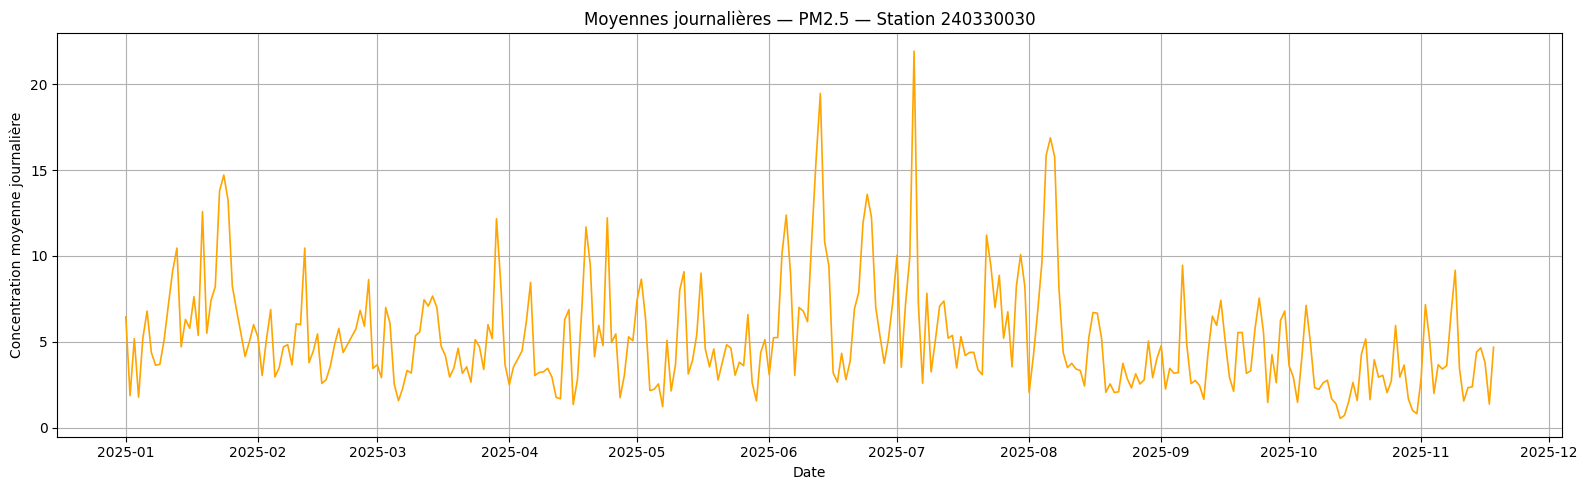

In [ ]:
#moyenne journalière
daily_mean = df.groupby("Date")["Value"].mean()

plt.figure(figsize=(16, 5))
plt.plot(daily_mean.index, daily_mean.values, color="orange", linewidth=1.2)
plt.title(f"Moyennes journalières — {pollutant} — Station {station_id}")
plt.xlabel("Date")
plt.ylabel("Concentration moyenne journalière")
plt.grid(True)
plt.tight_layout()
plt.show()

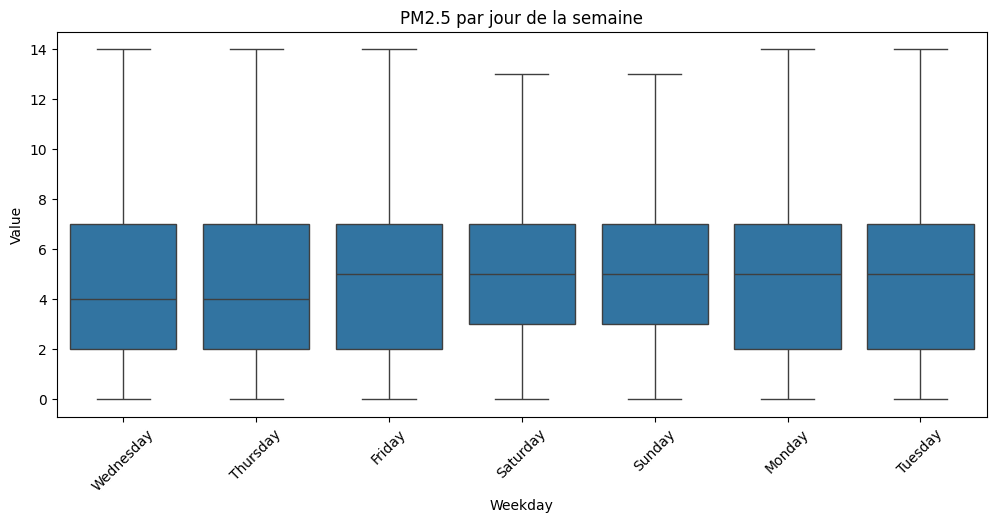

In [ ]:
df["Weekday"] = df.index.day_name()

plt.figure(figsize=(12,5))
sns.boxplot(x="Weekday", y="Value", data=df, showfliers=False)
plt.xticks(rotation=45)
plt.title("PM2.5 par jour de la semaine")
plt.show()

In [ ]:
df["Value"].describe()

,Value
count,274521.000000
mean,5.406592
std,4.324900
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,62.000000


In [ ]:
monthly_stats = df.groupby("Month")["Value"].describe()
monthly_stats

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
1,27807.0,6.963534,4.488347,0.0,4.0,6.0,9.0,33.0
2,22308.0,5.062937,3.054852,0.0,3.0,4.0,7.0,17.0
3,26637.0,4.970717,3.591462,0.0,2.0,4.0,7.0,19.0
4,26247.0,4.924220,3.825990,0.0,2.0,4.0,7.0,22.0
5,24648.0,4.670886,3.373350,0.0,2.0,4.0,6.0,18.0
6,26988.0,7.865607,5.950107,0.0,4.0,7.0,11.0,62.0
7,27846.0,6.889356,4.960190,0.0,4.0,6.0,9.0,43.0
8,27378.0,5.350427,4.942176,0.0,2.0,4.0,6.0,25.0
9,26403.0,4.521418,2.952395,0.0,2.0,4.0,6.0,18.0


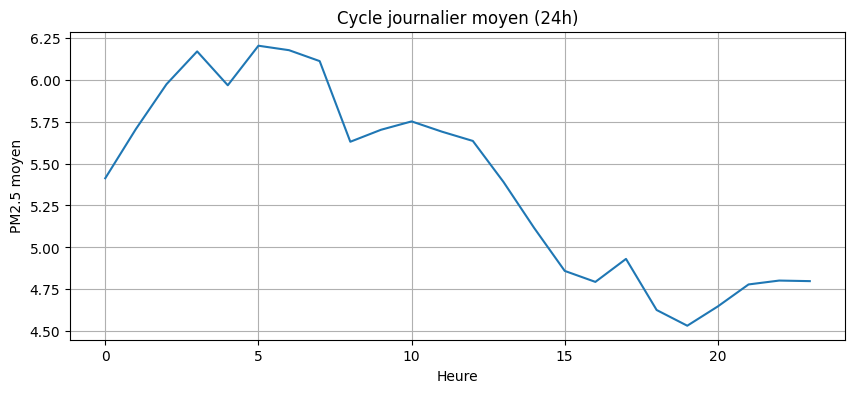

In [ ]:
df["Hour"] = df.index.hour
hourly_mean = df.groupby("Hour")["Value"].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_mean.index, hourly_mean.values)
plt.title("Cycle journalier moyen (24h)")
plt.xlabel("Heure")
plt.ylabel("PM2.5 moyen")
plt.grid(True)
plt.show()

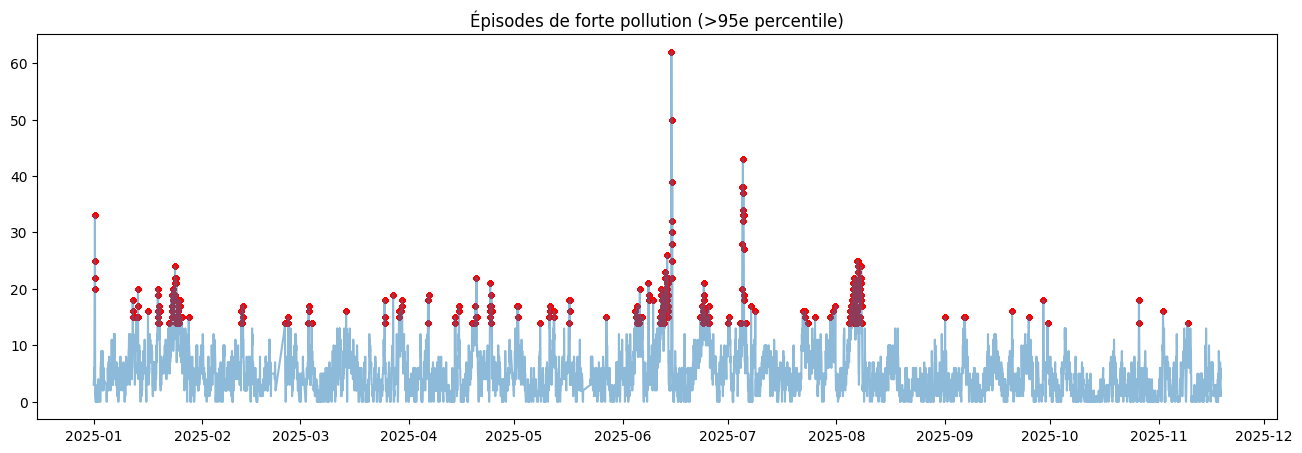

In [ ]:
q95 = df["Value"].quantile(0.95)
extremes = df[df["Value"] > q95]
plt.figure(figsize=(16,5))
plt.plot(df.index, df["Value"], alpha=0.5)
plt.scatter(extremes.index, extremes["Value"], color="red", s=10)
plt.title("Épisodes de forte pollution (>95e percentile)")
plt.show()

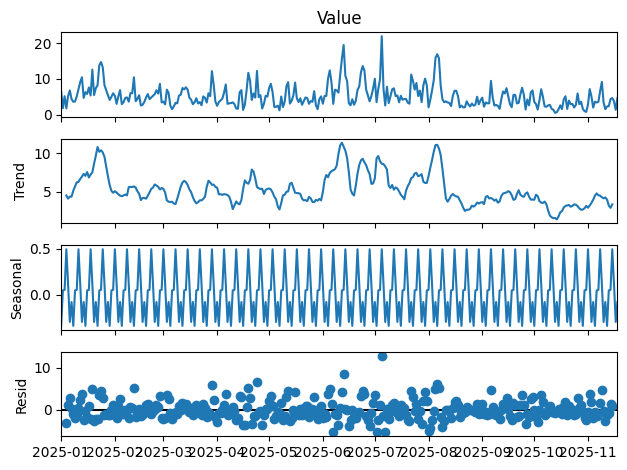

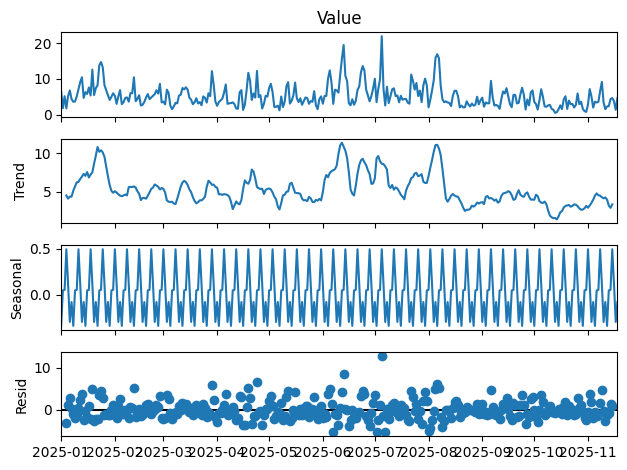

In [ ]:
if not isinstance(df.index, pd.DatetimeIndex):
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")

daily = df["Value"].resample("D").mean()
daily = daily.interpolate(method='time')
decomp = seasonal_decompose(daily, model="additive", period=7)
decomp.plot()

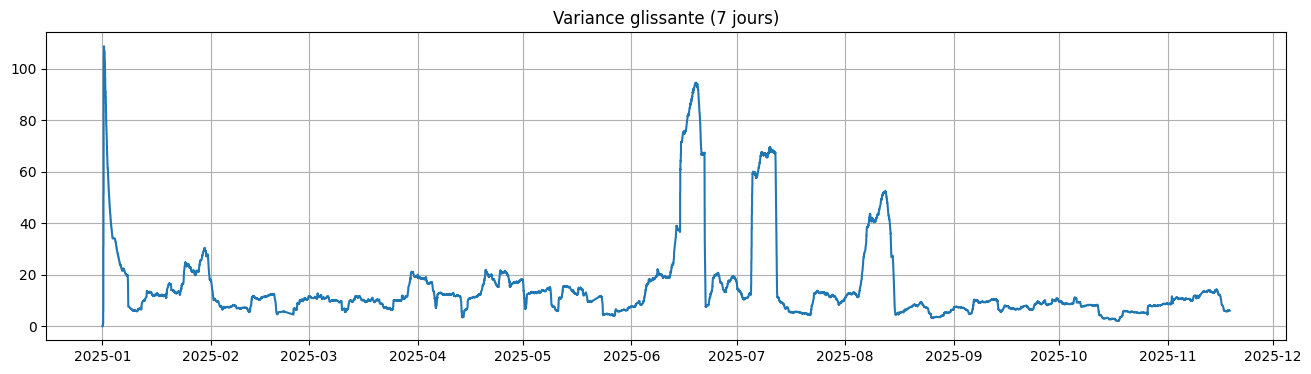

In [ ]:
rolling_var = df["Value"].rolling("7D").var()
plt.figure(figsize=(16,4))
plt.plot(rolling_var)
plt.title("Variance glissante (7 jours)")
plt.grid(True)
plt.show()

In [ ]:
rolling_mean = df["Value"].rolling("7D").mean()
rolling_std  = df["Value"].rolling("7D").std()

z_score = (df["Value"] - rolling_mean) / rolling_std
anomalies = df[abs(z_score) > 3]
anomalies

,Value,Month,Day,Date,Weekday,Hour
timestamp,,,,,,
2025-01-01 01:00:00,4.0,1,1,2025-01-01,Wednesday,1
2025-01-01 01:00:00,4.0,1,1,2025-01-01,Wednesday,1
2025-01-01 01:00:00,4.0,1,1,2025-01-01,Wednesday,1
2025-01-01 01:00:00,4.0,1,1,2025-01-01,Wednesday,1
2025-01-01 03:00:00,6.0,1,1,2025-01-01,Wednesday,3
...,...,...,...,...,...,...
2025-11-02 12:00:00,13.0,11,2,2025-11-02,Sunday,12
2025-11-02 12:00:00,13.0,11,2,2025-11-02,Sunday,12
2025-11-02 12:00:00,13.0,11,2,2025-11-02,Sunday,12


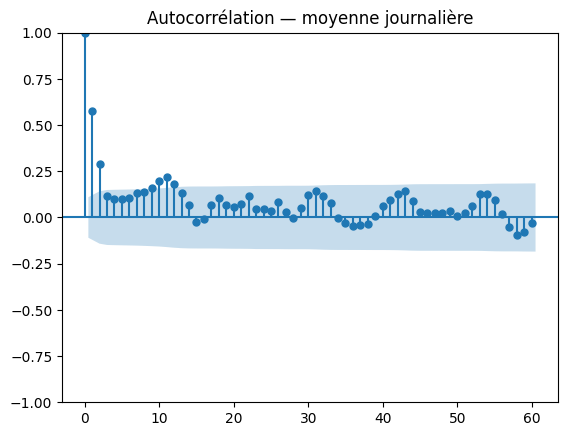

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

daily = df["Value"].resample("D").mean().dropna()
#~2 mois
plot_acf(daily, lags=60)
plt.title("Autocorrélation — moyenne journalière")
plt.show()

# Comparaison de la concentration sur plusieurs villes des USA

In [ ]:
cities = [
    "New York",
    "Los Angeles",
    "Chicago",
    "Houston",
    "Phoenix",
    "Los Angeles",
    "Boston",
    "San Francisco"
]

pollutants = ["PM2.5", "PM10", "OZONE"]

con = duckdb.connect()

query = f"""
SELECT
    ReportingAreaName,
    StateCode,
    Parameter,
    SiteID,
    timestamp,
    CAST(Value AS DOUBLE) AS Value
FROM parquet_scan('AirNow_2025_clean.parquet')
WHERE
    ReportingAreaName IN {tuple(cities)}
    AND Parameter IN {tuple(pollutants)}
    AND Value IS NOT NULL
    AND CAST(Value AS DOUBLE) >= 0
"""

df = con.execute(query).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df["Date"] = df.index.date
df["Month"] = df.index.month

daily = (
    df
    .groupby(["ReportingAreaName", "Parameter", "Date", "SiteID"])["Value"]
    .mean()
    .reset_index()
)

daily["Date"] = pd.to_datetime(daily["Date"])


In [ ]:
daily_city = (
    daily
    .groupby(["ReportingAreaName", "Parameter", "Date"])["Value"]
    .mean()
    .reset_index()
)

daily_city["Date"] = pd.to_datetime(daily_city["Date"])

stations_per_city = (
    df.groupby("ReportingAreaName")["SiteID"].nunique()
)

stations_per_city


,SiteID
ReportingAreaName,
Boston,3
Chicago,6
Phoenix,22
San Francisco,1


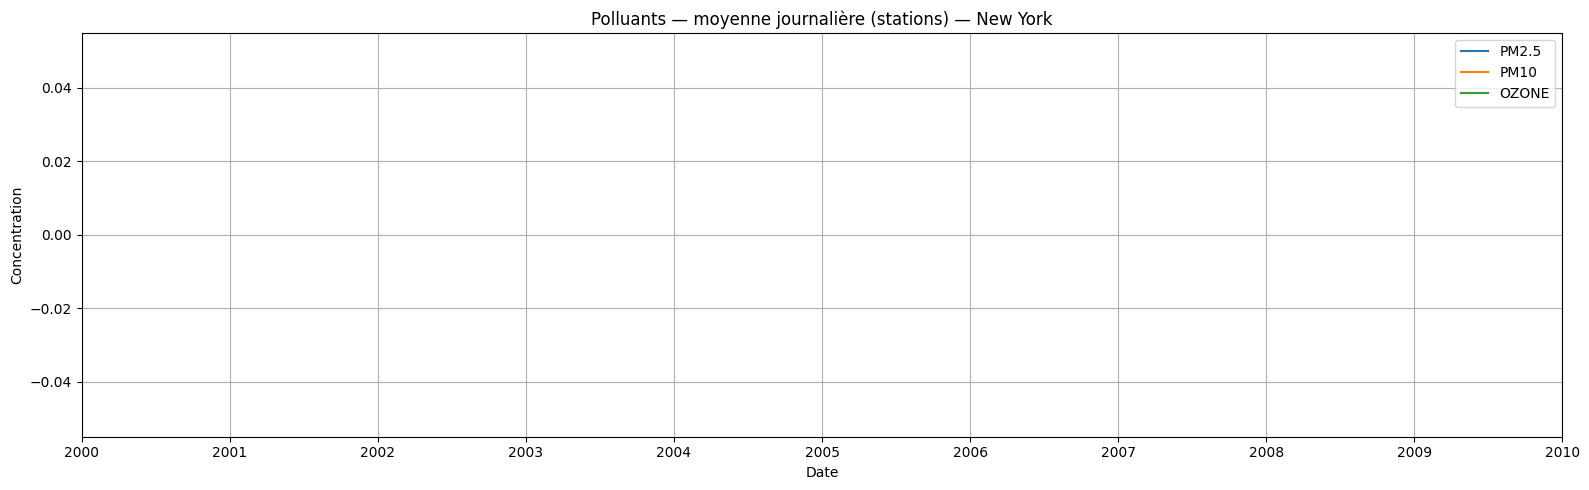

In [ ]:
city = "New York"

plt.figure(figsize=(16,5))
for pol in pollutants:
    subset = daily_city[
        (daily_city["ReportingAreaName"] == city) &
        (daily_city["Parameter"] == pol)
    ]
    plt.plot(subset["Date"], subset["Value"], label=pol)

plt.title(f"Polluants — moyenne journalière (stations) — {city}")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

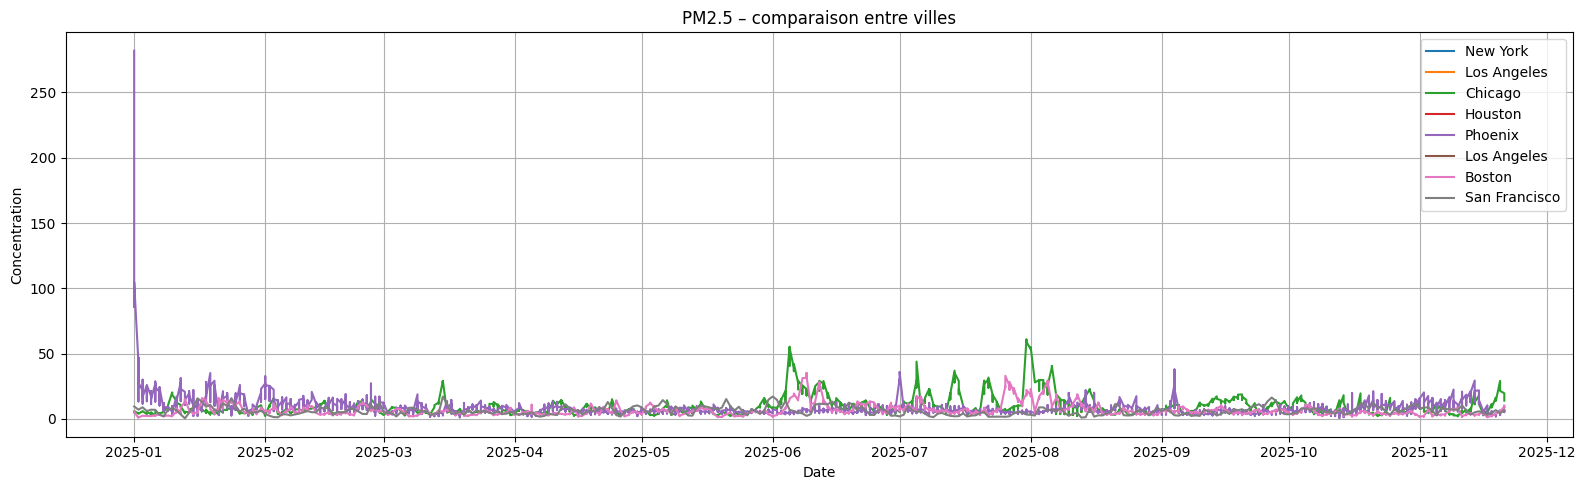

In [ ]:
pollutant = "PM2.5"

plt.figure(figsize=(16,5))
for city in cities:
    subset = daily[
        (daily["ReportingAreaName"] == city) &
        (daily["Parameter"] == pollutant)
    ]
    plt.plot(subset["Date"], subset["Value"], label=city)

plt.title(f"PM2.5 – comparaison entre villes")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


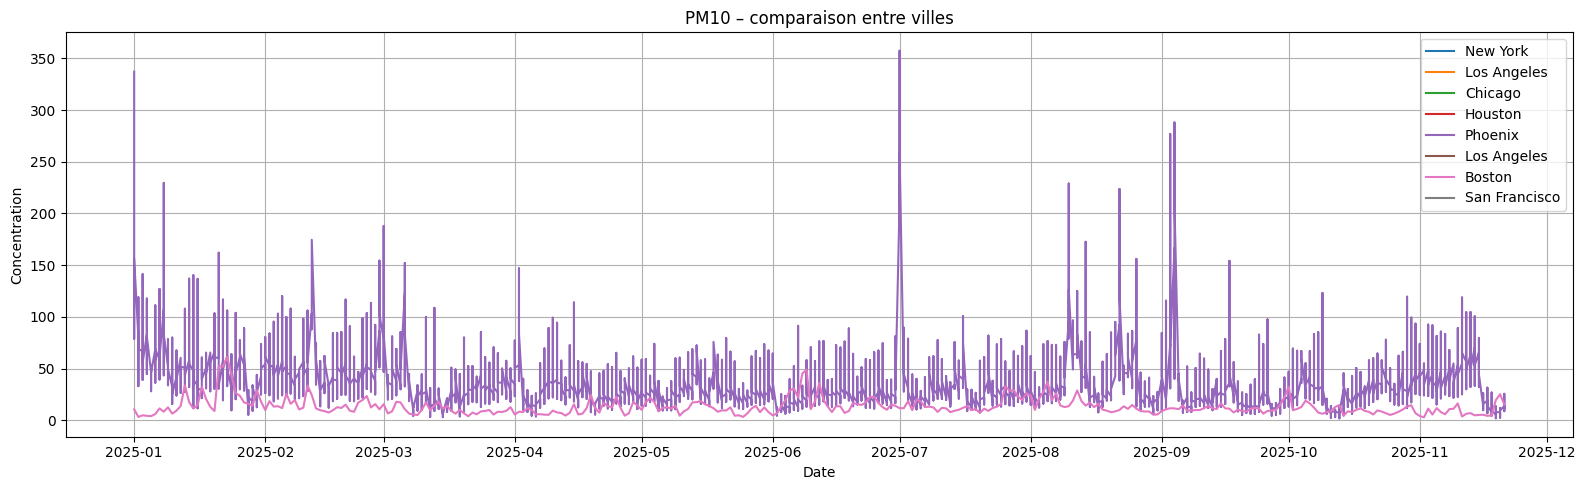

In [ ]:
pollutant = "PM10"

plt.figure(figsize=(16,5))
for city in cities:
    subset = daily[
        (daily["ReportingAreaName"] == city) &
        (daily["Parameter"] == pollutant)
    ]
    plt.plot(subset["Date"], subset["Value"], label=city)

plt.title(f"PM10 – comparaison entre villes")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


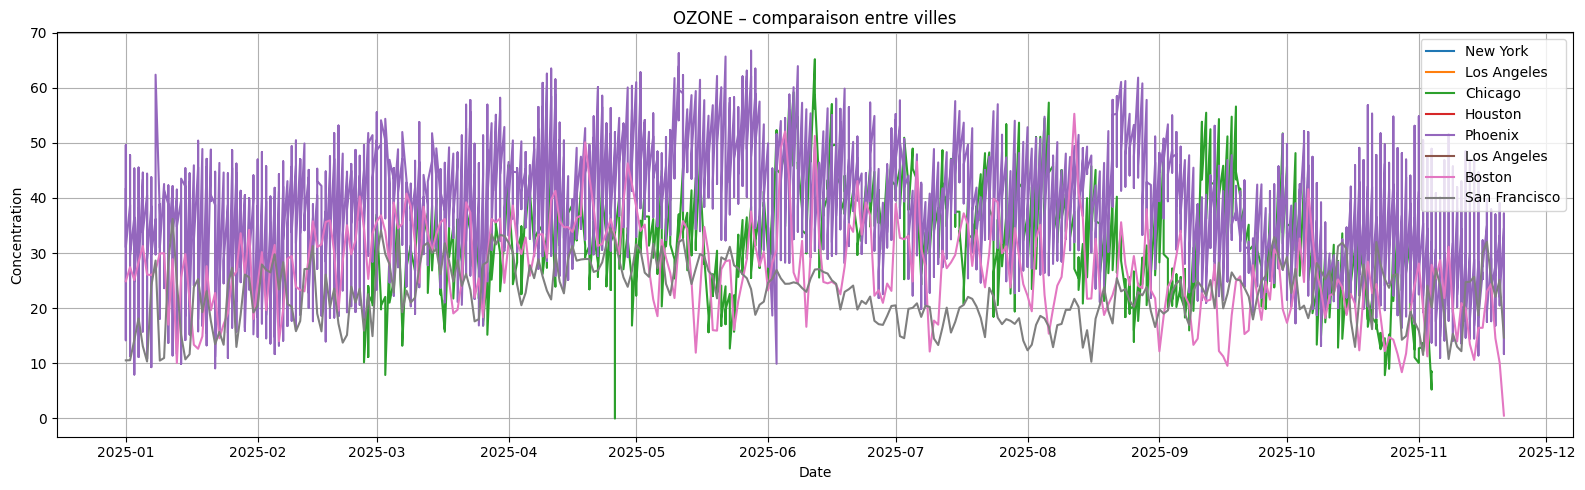

In [ ]:
pollutant = "OZONE"

plt.figure(figsize=(16,5))
for city in cities:
    subset = daily[
        (daily["ReportingAreaName"] == city) &
        (daily["Parameter"] == pollutant)
    ]
    plt.plot(subset["Date"], subset["Value"], label=city)

plt.title(f"OZONE – comparaison entre villes")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


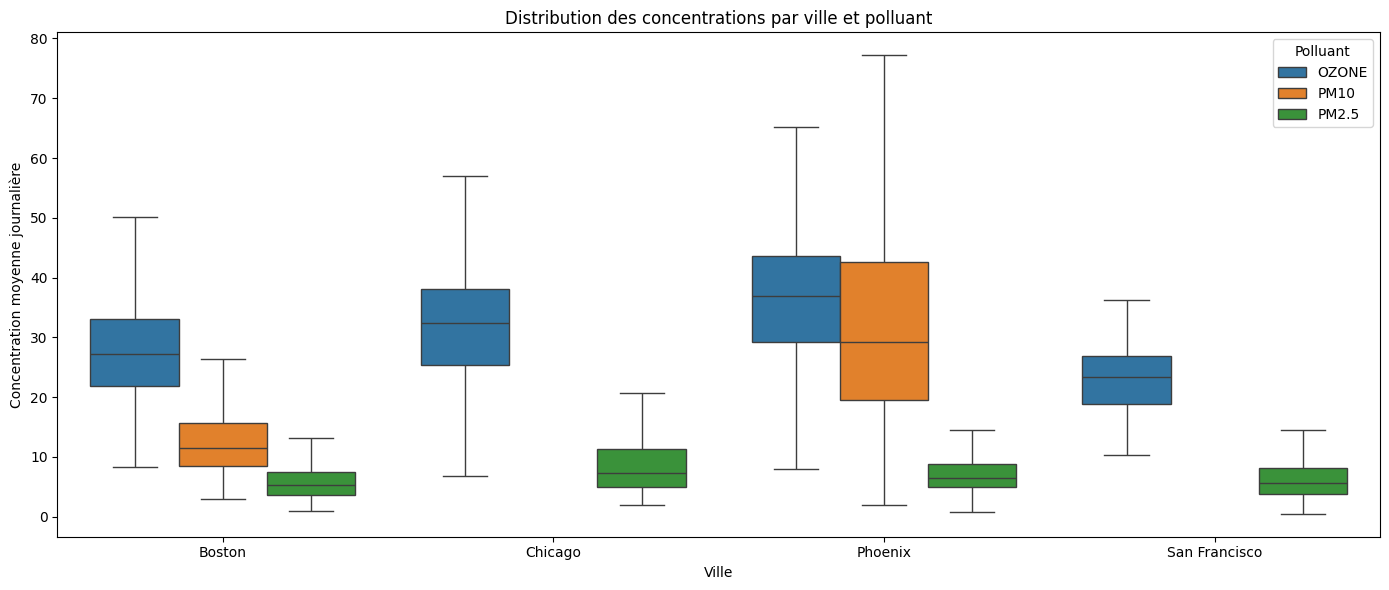

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=daily,
    x="ReportingAreaName",
    y="Value",
    hue="Parameter",
    showfliers=False
)

plt.title("Distribution des concentrations par ville et polluant")
plt.ylabel("Concentration moyenne journalière")
plt.xlabel("Ville")
plt.legend(title="Polluant")
plt.tight_layout()
plt.show()


In [ ]:
summary=(
    daily
    .groupby(["ReportingAreaName", "Parameter"])["Value"]
    .agg(["mean", "median", "std", "max"])
    .round(2)
)
summary


mean  median    std     max
ReportingAreaName Parameter                              
Boston            OZONE      27.20   27.25   8.46   55.26
                  PM10       13.34   11.54   8.18   61.42
                  PM2.5       6.53    5.30   4.70   35.27
Chicago           OZONE      31.97   32.33   9.75   65.17
                  PM2.5       9.34    7.30   7.29   61.05
Phoenix           OZONE      36.37   36.89  10.21   66.71
                  PM10       35.71   29.27  28.54  357.33
                  PM2.5       8.22    6.53   9.84  281.93
San Francisco     OZONE      22.85   23.39   5.59   36.18
                  PM2.5       6.28    5.69   3.29   17.21

# Prévision concentration PM2.5 à horizons t+1 et t+7

In [ ]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
city="Phoenix"
ts=(
    daily[
        (daily["ReportingAreaName"] == city) &
        (daily["Parameter"] == "PM2.5")
    ]
    .sort_values("Date")
    .set_index("Date")["Value"]
)
ts.head()

,Value
Date,
2025-01-01,281.933333
2025-01-01,150.416667
2025-01-01,86.708333
2025-01-01,102.175000
2025-01-01,250.083333


In [ ]:
df_m = pd.DataFrame({"y": ts})

#Cibles
df_m["y_t+1"] = df_m["y"].shift(-1)
df_m["y_t+7"] = df_m["y"].shift(-7)

#Lags
for lag in [1, 2, 3, 7, 14, 21]:
    df_m[f"lag_{lag}"] = df_m["y"].shift(lag)

#Rolling features
df_m["roll_mean_7"] = df_m["y"].rolling(7).mean()
df_m["roll_std_7"] = df_m["y"].rolling(7).std()
df_m["roll_mean_14"] = df_m["y"].rolling(14).mean()
df_m["roll_std_14"] = df_m["y"].rolling(14).std()

#Calendrier
df_m["dow"] = df_m.index.dayofweek
df_m["month"] = df_m.index.month

df_m["dow_sin"] = np.sin(2 * np.pi * df_m["dow"] / 7)
df_m["dow_cos"] = np.cos(2 * np.pi * df_m["dow"] / 7)

df_m["month_sin"] = np.sin(2 * np.pi * df_m["month"] / 12)
df_m["month_cos"] = np.cos(2 * np.pi * df_m["month"] / 12)

df_m = df_m.dropna()


### Régression Linéaire à t+1

In [ ]:
window = 365  # 1 an
preds, y_true, dates = [], [], []

features = df_m.drop(columns=["y", "y_t+1", "y_t+7"]).columns

for i in range(window, len(df_m)):
    train = df_m.iloc[i-window:i]
    test = df_m.iloc[i]

    X_train = train[features]
    y_train = train["y_t+1"]

    X_test = test[features].values.reshape(1, -1)

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds.append(model.predict(X_test)[0])
    y_true.append(test["y_t+1"])
    dates.append(test.name)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitte

In [ ]:
baseline_preds = df_m["lag_1"].iloc[window:]
baseline_true = df_m["y_t+1"].iloc[window:]

In [ ]:
mae_model = mean_absolute_error(y_true, preds)
mae_baseline = mean_absolute_error(baseline_true, baseline_preds)

print(f"MAE modèle (t+1)     : {mae_model:.2f}")
print(f"MAE baseline naïve   : {mae_baseline:.2f}")


MAE modèle (t+1)     : 1.76
MAE baseline naïve   : 2.03


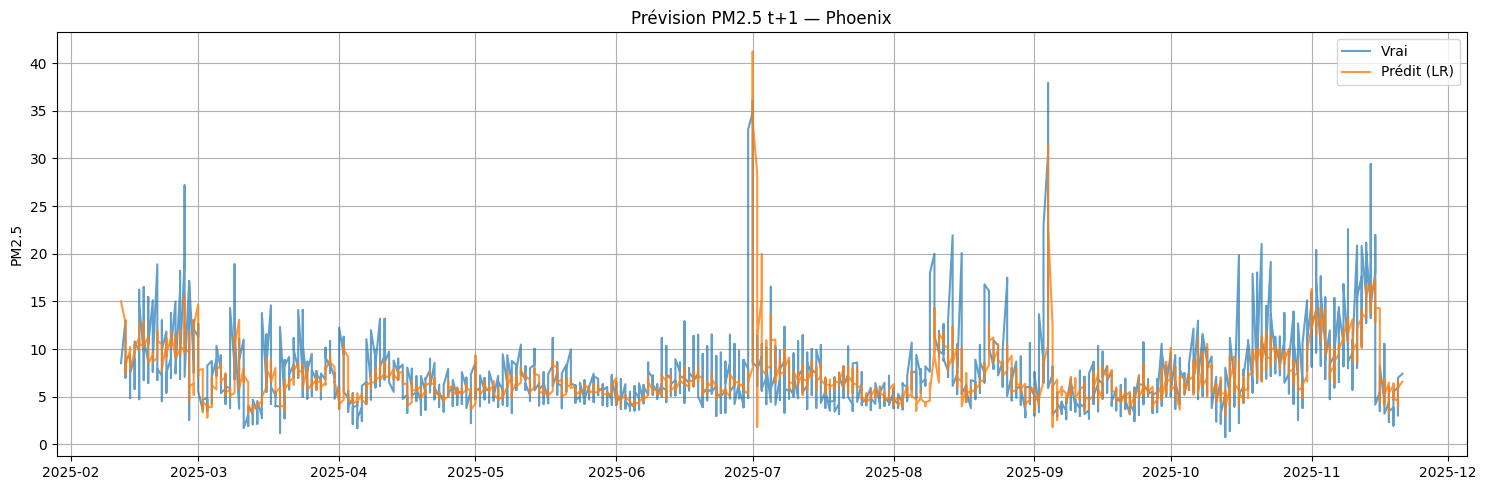

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(dates, y_true, label="Vrai", alpha=0.7)
plt.plot(dates, preds, label="Prédit (LR)", alpha=0.8)
plt.title(f"Prévision PM2.5 t+1 — {city}")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
split_date = "2025-10-01"
train = df_m[df_m.index < split_date]
test = df_m[df_m.index >= split_date]

X_train = train.drop(columns=["y", "y_t+1", "y_t+7"])
X_test = test.drop(columns=["y", "y_t+1", "y_t+7"])

In [ ]:
scaler = StandardScaler()

X = df_m.drop(columns=["y", "y_t+1", "y_t+7"])
y = df_m["y_t+1"]

batch_size = 256

sgd = SGDRegressor(
    loss="squared_error",
    learning_rate="adaptive",
    eta0=0.01,
    random_state=42
)

for i in range(0, len(X_train), batch_size):
    X_batch = X_train.iloc[i:i+batch_size]
    y_batch = train["y_t+1"].iloc[i:i+batch_size]

    X_batch_scaled = scaler.partial_fit(X_batch).transform(X_batch)

    sgd.partial_fit(X_batch_scaled, y_batch)

X_test_scaled = scaler.transform(X_test)
y_pred_sgd = sgd.predict(X_test_scaled)


### Régression Linéaire à t+7

In [ ]:
window = 365
preds_7, y_true_7 = [], []

for i in range(window, len(df_m)):
    train = df_m.iloc[i-window:i]
    test = df_m.iloc[i]

    X_train = train[features]
    y_train = train["y_t+7"]

    X_test = test[features].values.reshape(1, -1)

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds_7.append(model.predict(X_test)[0])
    y_true_7.append(test["y_t+7"])


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitte

In [ ]:
mae_7 = mean_absolute_error(y_true_7, preds_7)
mse_7 = mean_squared_error(y_true_7, preds_7)
r2_7 = r2_score(y_true_7, preds_7)

print("Horizon t+7")
print(f"MAE: {mae_7:.2f}")
print(f"MSE: {mse_7:.2f}")
print(f"R²: {r2_7:.3f}")

Horizon t+7
MAE: 2.10
MSE: 11.21
R²: 0.091


### Random Forest à t+1

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

preds_rf, y_true_rf = [], []

for i in range(window, len(df_m)):
    train = df_m.iloc[i-window:i]
    test = df_m.iloc[i]

    rf.fit(train[features], train["y_t+1"])
    preds_rf.append(rf.predict(test[features].values.reshape(1, -1))[0])
    y_true_rf.append(test["y_t+1"])

print("Random Forest (t+1)")
print("MAE:", mean_absolute_error(y_true_rf, preds_rf))
print("MSE:", mean_squared_error(y_true_rf, preds_rf))
print("R²:", r2_score(y_true_rf, preds_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

KeyboardInterrupt: 